# 📊 Bloque 2 — Sesión 1: Concepto del AED e inspección inicial

**Módulo:** Depuración, limpieza y Clasificación de Datos (5109)  
**Unidad Didáctica:** UD1 — Análisis exploratorio de datos  
**Duración estimada:** ~4 horas.

---

### Contenidos de esta sesión
- **2.1** Concepto y fases del AED: inspección, descripción, visualización y síntesis
- **2.2** Inspección inicial del conjunto de datos: `shape`, `dtypes`, `head`, `info`, `describe`

### Criterio de evaluación asociado
> **(CE c)** Se han identificado la estructura, variables y relaciones de los conjuntos de datos aplicando técnicas exploratorias.

In [1]:
# Librerías necesarias para esta sesión
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración general de visualización
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['figure.dpi'] = 100

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


---
## 2.1 Concepto y fases del AED

El **Análisis Exploratorio de Datos** (AED, o EDA por sus siglas en inglés) es el proceso de examinar un conjunto de datos antes de aplicar cualquier modelo o técnica de Machine Learning. Fue popularizado por el estadístico **John Tukey** en los años 70.

> 🎯 **Objetivo del AED:** entender qué hay en los datos, cómo están organizados, qué calidad tienen y qué relaciones existen entre las variables, antes de tomar ninguna decisión de modelado.

### ¿Por qué es imprescindible el AED?

Un modelo de ML es tan bueno como los datos con los que se entrena. El AED permite detectar, antes de entrenar, problemas como:
- Variables con muchos valores ausentes
- Tipos de datos incorrectos
- Outliers que pueden distorsionar el modelo
- Variables redundantes o irrelevantes
- Desequilibrios en la variable objetivo (clases muy desbalanceadas)

### Fases del AED

```
1. INSPECCIÓN     → ¿Qué estructura tienen los datos? (shape, dtypes, head, info)
        ↓
2. DESCRIPCIÓN    → ¿Cómo se distribuye cada variable? (describe, value_counts, histogramas)
        ↓
3. VISUALIZACIÓN  → ¿Qué patrones o anomalías hay? (boxplots, scatter, heatmaps)
        ↓
4. SÍNTESIS       → ¿Qué conclusiones guían el preprocesado y el modelado?
```

En este bloque trabajaremos las cuatro fases progresivamente. Esta sesión cubre la **inspección** inicial.

### Dataset de trabajo: Titanic

A lo largo del Bloque 2 utilizaremos el dataset **Titanic**, uno de los más usados en aprendizaje automático. Contiene información sobre los pasajeros del transatlántico y si sobrevivieron o no al hundimiento.

Es un dataset ideal para practicar el AED porque:
- Tiene variables de todos los tipos (numéricas, categóricas, booleanas)
- Tiene valores ausentes reales
- Tiene outliers
- La variable objetivo (`survived`) está moderadamente desbalanceada

In [2]:
# Cargamos el dataset Titanic desde seaborn
titanic = sns.load_dataset('titanic')

print('Dataset Titanic cargado correctamente.')
print(f'Tipo: {type(titanic)}')

Dataset Titanic cargado correctamente.
Tipo: <class 'pandas.core.frame.DataFrame'>


---
## 2.2 Inspección inicial del conjunto de datos

La inspección inicial es el primer contacto con el dataset. El objetivo es responder a preguntas básicas:

| Pregunta | Herramienta |
|----------|-------------|
| ¿Cuántas filas y columnas tiene? | `df.shape` |
| ¿Cómo se llaman las columnas? | `df.columns` |
| ¿Qué tipo tiene cada columna? | `df.dtypes` |
| ¿Qué aspecto tienen los datos? | `df.head()`, `df.tail()`, `df.sample()` |
| ¿Hay valores ausentes? ¿Cuánta memoria ocupa? | `df.info()` |
| ¿Cómo se distribuyen las variables numéricas? | `df.describe()` |
| ¿Cuántos valores únicos tiene cada columna? | `df.nunique()` |

### 📌 Ejemplo 1 — `shape` y `columns`: estructura del dataset

In [3]:
# shape devuelve una tupla (nº filas, nº columnas)
print(f'Dimensiones: {titanic.shape[0]} filas × {titanic.shape[1]} columnas')
print(f'\nColumnas ({len(titanic.columns)}):')
for col in titanic.columns:
    print(f'  · {col}')

Dimensiones: 891 filas × 15 columnas

Columnas (15):
  · survived
  · pclass
  · sex
  · age
  · sibsp
  · parch
  · fare
  · embarked
  · class
  · who
  · adult_male
  · deck
  · embark_town
  · alive
  · alone


### 📌 Ejemplo 2 — `head`, `tail` y `sample`: vistazo a los datos

In [4]:
# head(n): muestra las primeras n filas (por defecto 5)
print('Primeras 5 filas (head):')
titanic.head()

Primeras 5 filas (head):


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
# tail(n): muestra las últimas n filas
print('Últimas 5 filas (tail):')
titanic.tail()

Últimas 5 filas (tail):


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [6]:
# sample(n): muestra n filas aleatorias — útil para ver registros del medio del dataset
print('5 filas aleatorias (sample):')
titanic.sample(5, random_state=42)

5 filas aleatorias (sample):


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
709,1,3,male,NaN,1,1,15.2458,C,Third,man,True,NaN,Cherbourg,yes,False
439,0,2,male,31.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
840,0,3,male,20.0,0,0,7.9250,S,Third,man,True,NaN,Southampton,no,True
720,1,2,female,6.0,0,1,33.0000,S,Second,child,False,NaN,Southampton,yes,False
39,1,3,female,14.0,1,0,11.2417,C,Third,child,False,NaN,Cherbourg,yes,False


### 📌 Ejemplo 3 — `dtypes`: tipos de datos asignados por pandas

In [7]:
# dtypes muestra el tipo de dato que pandas asignó a cada columna
print('Tipos de datos (dtypes):')
print(titanic.dtypes)

# Podemos agrupar columnas por tipo
print('\nColumnas numéricas:', titanic.select_dtypes(include='number').columns.tolist())
print('Columnas categóricas/texto:', titanic.select_dtypes(include=['object', 'category', 'string']).columns.tolist())
print('Columnas booleanas:', titanic.select_dtypes(include='bool').columns.tolist())

Tipos de datos (dtypes):
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

Columnas numéricas: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
Columnas categóricas/texto: ['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive']
Columnas booleanas: ['adult_male', 'alone']


### 📌 Ejemplo 4 — `info()`: resumen completo del DataFrame

In [8]:
# info() es la herramienta más completa para la inspección inicial:
# - nº de filas y columnas
# - nombre, tipo y cantidad de valores NO nulos por columna
# - memoria total ocupada
print('Resumen con info():')
titanic.info()

Resumen con info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [9]:
# Detectamos columnas con valores ausentes a partir de info()
# Una columna tiene ausentes si su nº de non-null < nº total de filas
total_filas = len(titanic)
ausentes = titanic.isnull().sum()
ausentes = ausentes[ausentes > 0].sort_values(ascending=False)

print(f'Total de filas: {total_filas}')
print(f'\nColumnas con valores ausentes:')
for col, n in ausentes.items():
    pct = n / total_filas * 100
    print(f'  {col:15s}: {n:3d} ausentes ({pct:.1f}%)')

Total de filas: 891

Columnas con valores ausentes:
  deck           : 688 ausentes (77.2%)
  age            : 177 ausentes (19.9%)
  embarked       :   2 ausentes (0.2%)
  embark_town    :   2 ausentes (0.2%)


### 📌 Ejemplo 5 — `describe()`: estadísticos descriptivos básicos

In [10]:
# describe() sobre variables numéricas: count, mean, std, min, percentiles, max
print('Estadísticos descriptivos — variables numéricas:')
titanic.describe().round(2)

Estadísticos descriptivos — variables numéricas:


,survived,pclass,age,sibsp,parch,fare
count,891.00,891.00,714.00,891.00,891.00,891.00
mean,0.38,2.31,29.70,0.52,0.38,32.20
std,0.49,0.84,14.53,1.10,0.81,49.69
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,20.12,0.00,0.00,7.91
50%,0.00,3.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,38.00,1.00,0.00,31.00
max,1.00,3.00,80.00,8.00,6.00,512.33


In [11]:
# describe(include='object') sobre variables categóricas: count, unique, top, freq
print('Estadísticos descriptivos — variables categóricas:')
titanic.describe(include=['string', 'object', 'category'])


Estadísticos descriptivos — variables categóricas:


,sex,embarked,class,who,deck,embark_town,alive
count,891,889,891,891,203,889,891
unique,2,3,3,3,7,3,2
top,male,S,Third,man,C,Southampton,no
freq,577,644,491,537,59,644,549


In [12]:
# describe(include='all') combina ambos en una sola tabla
print('Estadísticos descriptivos — todas las variables:')
titanic.describe(include='all').round(2)

Estadísticos descriptivos — todas las variables:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.00,891.00,891,714.00,891.00,891.00,891.00,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.38,2.31,NaN,29.70,0.52,0.38,32.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.49,0.84,NaN,14.53,1.10,0.81,49.69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.00,1.00,NaN,0.42,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.00,2.00,NaN,20.12,0.00,0.00,7.91,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.00,3.00,NaN,28.00,0.00,0.00,14.45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.00,3.00,NaN,38.00,1.00,0.00,31.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 📌 Ejemplo 6 — `nunique` y `value_counts`: valores únicos

In [13]:
# nunique(): número de valores distintos por columna
# Es útil para detectar si una variable «numérica» es en realidad categórica
print('Número de valores únicos por columna:')
print(titanic.nunique().sort_values())

print('\n💡 Observación:')
print('  - pclass tiene solo 3 valores únicos → es categórica ordinal, no numérica')
print('  - survived tiene 2 → booleana')
print('  - fare tiene 248 → continua')

Número de valores únicos por columna:
survived         2
sex              2
alive            2
adult_male       2
alone            2
class            3
pclass           3
embarked         3
embark_town      3
who              3
sibsp            7
parch            7
deck             7
age             88
fare           248
dtype: int64

💡 Observación:
  - pclass tiene solo 3 valores únicos → es categórica ordinal, no numérica
  - survived tiene 2 → booleana
  - fare tiene 248 → continua


In [14]:
# value_counts(): frecuencia de cada valor en una columna
# normalize=True devuelve proporciones en lugar de conteos
print('Distribución de la variable objetivo — survived:')
print(titanic['survived'].value_counts())
print()
print(titanic['survived'].value_counts(normalize=True).round(3))

print('\n💡 El 38.4% de los pasajeros sobrevivió → clases desbalanceadas.')

print('\nDistribución de pclass:')
print(titanic['pclass'].value_counts().sort_index())

Distribución de la variable objetivo — survived:
survived
0    549
1    342
Name: count, dtype: int64

survived
0    0.616
1    0.384
Name: proportion, dtype: float64

💡 El 38.4% de los pasajeros sobrevivió → clases desbalanceadas.

Distribución de pclass:
pclass
1    216
2    184
3    491
Name: count, dtype: int64


### 📌 Ejemplo 7 — Informe de inspección inicial automatizado

Podemos crear una función reutilizable que ejecute toda la inspección inicial de un DataFrame de forma sistemática.

In [15]:
def inspeccionar(df, nombre='Dataset'):
    """Ejecuta la inspección inicial completa de un DataFrame."""
    sep = '─' * 55
    print(f'\n{sep}')
    print(f'  INSPECCIÓN INICIAL: {nombre}')
    print(sep)

    # 1. Dimensiones
    print(f'\n📐 Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas')

    # 2. Tipos de datos
    print(f'\n🔡 Tipos de datos:')
    tipos = df.dtypes.value_counts()
    for dtype, n in tipos.items():
        cols = df.select_dtypes(include=dtype).columns.tolist()
        print(f'   {str(dtype):12s}: {n} columna/s → {cols}')

    # 3. Valores ausentes
    ausentes = df.isnull().sum()
    ausentes = ausentes[ausentes > 0].sort_values(ascending=False)
    if ausentes.empty:
        print('\n✅ Sin valores ausentes.')
    else:
        print(f'\n⚠️  Valores ausentes ({len(ausentes)} columna/s):')
        for col, n in ausentes.items():
            print(f'   {col:20s}: {n:4d} ({n/len(df)*100:.1f}%)')

    # 4. Duplicados
    n_dup = df.duplicated().sum()
    print(f'\n🔁 Filas duplicadas: {n_dup}')

    # 5. Muestra
    print(f'\n📋 Primeras 3 filas:')
    print(df.head(3).to_string())
    print(sep)

# Aplicamos la función al Titanic
inspeccionar(titanic, 'Titanic')


───────────────────────────────────────────────────────
  INSPECCIÓN INICIAL: Titanic
───────────────────────────────────────────────────────

📐 Dimensiones: 891 filas × 15 columnas

🔡 Tipos de datos:
   object      : 5 columna/s → ['sex', 'embarked', 'who', 'embark_town', 'alive']
   int64       : 4 columna/s → ['survived', 'pclass', 'sibsp', 'parch']
   float64     : 2 columna/s → ['age', 'fare']
   bool        : 2 columna/s → ['adult_male', 'alone']
   category    : 1 columna/s → ['class', 'deck']
   category    : 1 columna/s → ['class', 'deck']

⚠️  Valores ausentes (4 columna/s):
   deck                :  688 (77.2%)
   age                 :  177 (19.9%)
   embarked            :    2 (0.2%)
   embark_town         :    2 (0.2%)

🔁 Filas duplicadas: 107

📋 Primeras 3 filas:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class    who  adult_male deck  embark_town alive  alone
0         0       3    male  22.0      1      0   7.2500        S  Third    man        T

### 📌 Ejemplo 8 — Visualización rápida de ausentes con un mapa de calor

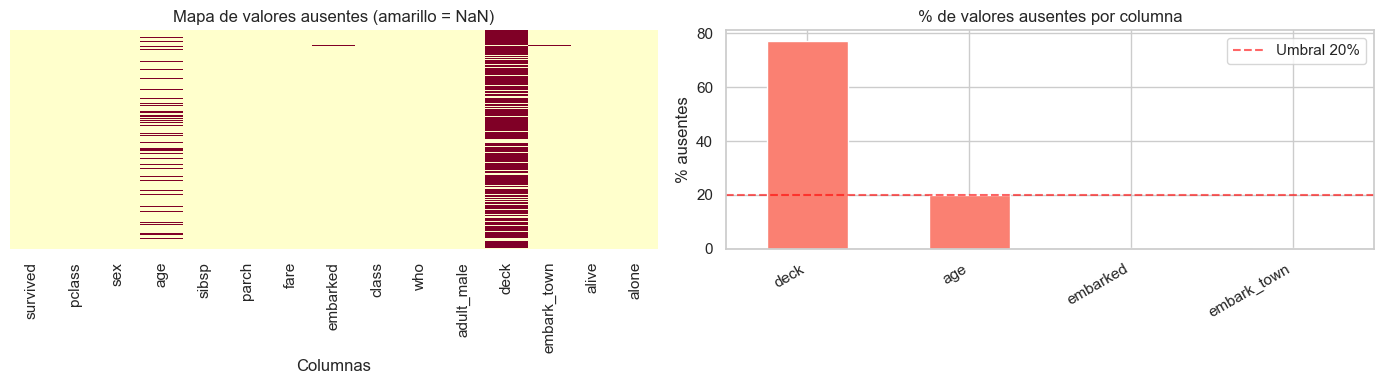

💡 "deck" tiene más del 77% de ausentes → candidata a ser descartada del análisis.


In [16]:
# Mapa de calor de valores ausentes: cada fila es un registro, cada columna una variable
# Los valores NaN aparecen en color claro
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Mapa de calor de presencia/ausencia
sns.heatmap(
    titanic.isnull(),
    ax=axes[0],
    cbar=False,
    yticklabels=False,
    cmap='YlOrRd'
)
axes[0].set_title('Mapa de valores ausentes (amarillo = NaN)')
axes[0].set_xlabel('Columnas')

# Porcentaje de ausentes por columna
pct_ausentes = titanic.isnull().mean() * 100
pct_ausentes = pct_ausentes[pct_ausentes > 0].sort_values(ascending=False)
pct_ausentes.plot(kind='bar', ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('% de valores ausentes por columna')
axes[1].set_ylabel('% ausentes')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].axhline(y=20, color='red', linestyle='--', alpha=0.6, label='Umbral 20%')
axes[1].legend()

plt.tight_layout()
plt.show()

print('💡 "deck" tiene más del 77% de ausentes → candidata a ser descartada del análisis.')

---
### 🔧 Ejercicio 1 — Inspección del dataset Diamonds

El dataset **Diamonds** (disponible en seaborn) contiene características y precios de más de 50.000 diamantes. Realiza la inspección inicial completa.

In [17]:
# Carga el dataset
diamonds = sns.load_dataset('diamonds')

# TAREA 1: ¿Cuántas filas y columnas tiene?
# print(diamonds.shape)

# TAREA 2: ¿Qué tipo tiene cada columna? ¿Coincide con su tipo estadístico real?
# print(diamonds.dtypes)

# TAREA 3: Muestra las primeras filas y una muestra aleatoria de 5 registros
# print(diamonds.head())
# print(diamonds.sample(5))

# TAREA 4: Usa info() para detectar si hay valores ausentes
# diamonds.info()

# TAREA 5: Usa describe() para ver los estadísticos de las variables numéricas
# print(diamonds.describe().round(2))

# TAREA 6: Aplica la función inspeccionar() definida en el Ejemplo 7
# inspeccionar(diamonds, 'Diamonds')

# TAREA 7 (reflexión): ¿Hay variables que parezcan numéricas pero sean categóricas?
#                      ¿Cuántas clases tiene la variable 'cut'? ¿Y 'color'?
# Escribe tu respuesta como comentario:
# Respuesta: ...

print('Completa las tareas comentadas arriba.')

Completa las tareas comentadas arriba.


---
### 🔧 Ejercicio 2 — Diagnóstico rápido del dataset Penguins

El dataset **Penguins** contiene medidas morfológicas de pingüinos de tres especies. Es el sustituto moderno del Iris.

In [18]:
penguins = sns.load_dataset('penguins')

# TAREA 1: Inspección inicial completa (usa la función inspeccionar())
# inspeccionar(penguins, 'Penguins')

# TAREA 2: ¿Qué columnas tienen valores ausentes y en qué porcentaje?
# Muestra solo las columnas con al menos un ausente
# ...

# TAREA 3: ¿Cuántos pingüinos hay de cada especie? Usa value_counts()
# print(penguins['species'].value_counts())

# TAREA 4: ¿Cuántos valores únicos tiene cada columna?
# print(penguins.nunique())

# TAREA 5 (reflexión): A partir de la inspección, ¿qué problemas anticipas
#                      que habrá que resolver antes de entrenar un modelo?
# Respuesta: ...

print('Completa las tareas comentadas arriba.')

Completa las tareas comentadas arriba.


---
## 📝 Resumen de la sesión

| Concepto | Clave |
|----------|-------|
| AED | Proceso previo al modelado: inspeccionar, describir, visualizar y sintetizar los datos. |
| `shape` | `(filas, columnas)` — tamaño del dataset. |
| `head / tail / sample` | Vistazo a los datos. `sample` evita el sesgo de ver solo el principio. |
| `dtypes` | Tipos que pandas asignó. No siempre coinciden con el tipo estadístico real. |
| `info()` | Resumen completo: tipos, non-null counts y memoria. Detecta ausentes de un vistazo. |
| `describe()` | Estadísticos básicos: count, mean, std, min, percentiles, max. |
| `nunique()` | Valores distintos por columna. Ayuda a identificar variables categóricas enmascaradas. |
| `value_counts()` | Frecuencia de cada valor. Imprescindible para la variable objetivo. |

### 🔜 Próxima sesión
**Bloque 2 — Sesión 2:** Análisis de variables numéricas, categóricas y relaciones entre variables (histogramas, boxplots, correlaciones, heatmaps).